### **Problem statement**

- PySpark is python API to work with Apache Spark

- PySpark is a library for working with large datasets in a distributed computing environment where as Pandas is a useful to work with tabular datasets on a single machine [3]

#### **PySpark Data Cleaning**

Data Cleaning with PySpark - This task involves several challenges including :

- Handing the missing Data
- Presence of errors in the Data / inaccuracies
- Careful understanding of Outliers in the Data
- Presence of Duplicate or redundant data
- Can be time consuming
- Imputing the data carefully


[1] https://www.kaggle.com/datasets/rajeshrampure/black-friday-sale

[2] https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.Imputer.html

[3] https://medium.com/geekculture/pandas-vs-pyspark-fe110c266e5c

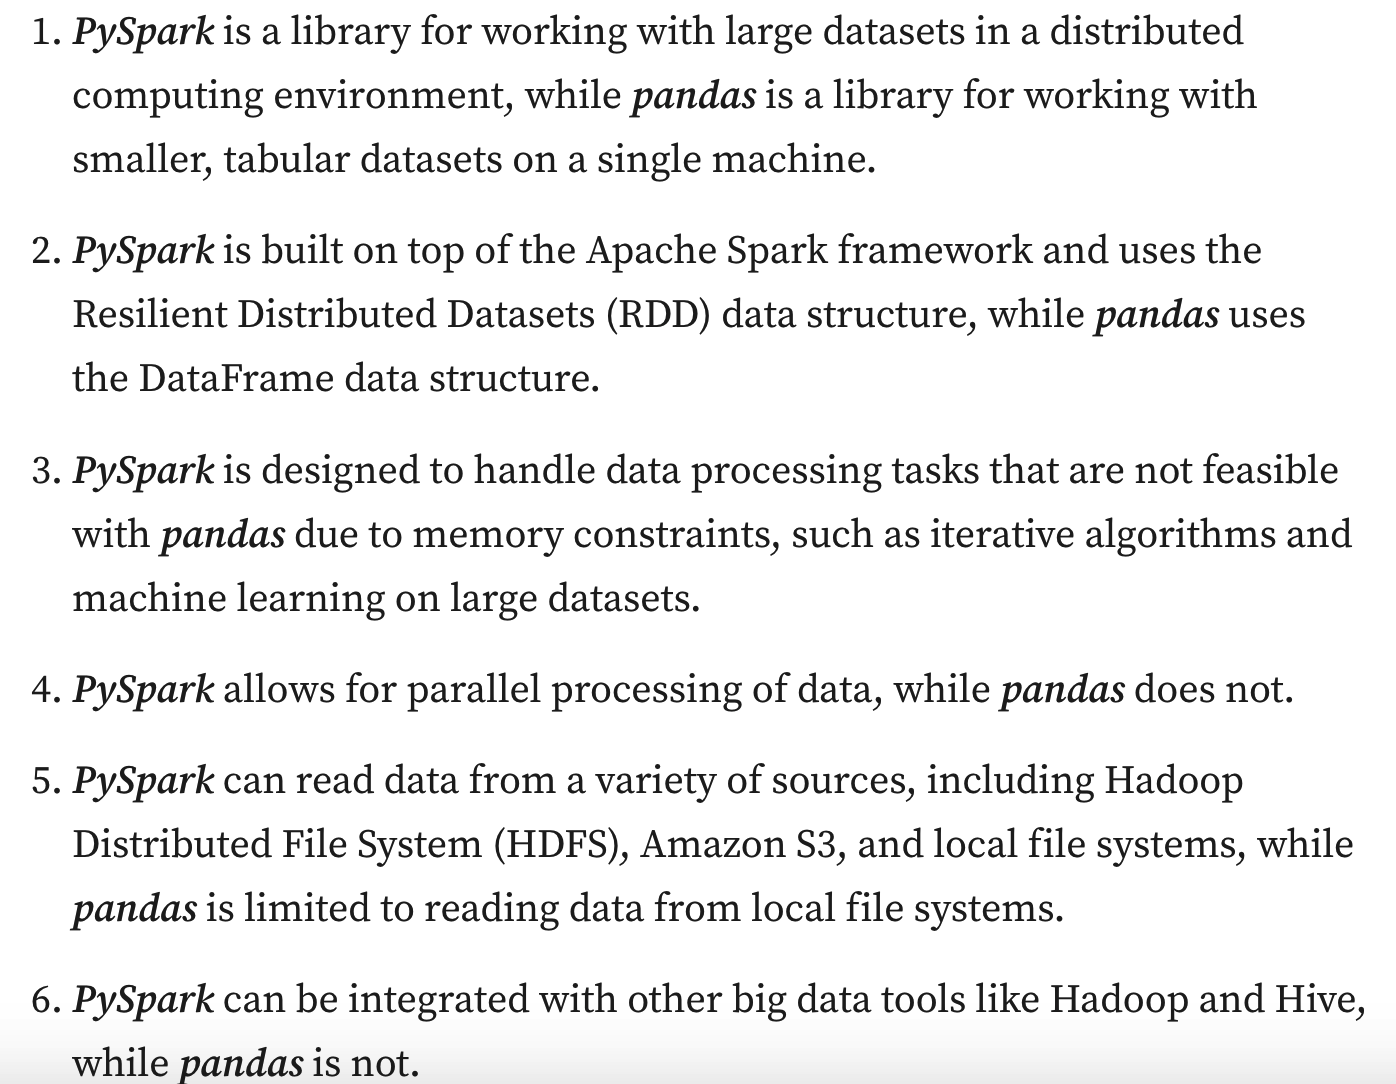

###**Setting up Spark environment variables and installing dependencies**

In [ ]:
import os # Importing the OS module

# Installing OpenJDK environment for running Spark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# Downloading Apache Spark 3.5.0 with Hadoop quietly
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

# Extract the Spark Package
!tar xf spark-3.5.1-bin-hadoop3.tgz

# Set JAVA_HOME environment path pointing to where OpenJDK is installed
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Set SPARK_HOME environment path pointing to where Spark is installed
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

In [ ]:
# Lists files and directories in current working directory
!ls

drive			 spark-3.5.1-bin-hadoop3.tgz	spark-3.5.1-bin-hadoop3.tgz.3
sample_data		 spark-3.5.1-bin-hadoop3.tgz.1	spark-3.5.1-bin-hadoop3.tgz.4
spark-3.5.1-bin-hadoop3  spark-3.5.1-bin-hadoop3.tgz.2	spark-3.5.1-bin-hadoop3.tgz.5


In [ ]:
# Installing the findspark package - necessary to run spark from Jupyter Notebook
!pip install findspark

# Importing findspark library
import findspark

# Initializing Pyspark - locates spark installation
findspark.init()



### **A higher level and a slightly more straight forward approach for PySpark installation**



In [ ]:
#!pip install pyspark

In [ ]:
# Installing Plotly for interactive Data Visualization

!pip install plotly --quiet

### **Importing dependencies**

In [ ]:
# Importing SparkSession from pyspark.sql, to create Spark entry points.
from pyspark.sql import SparkSession

In [ ]:
# Calling the builder method and getOrCreate to create or
# retrieving a SparkSession
# spark runs locally with available cores

spark = SparkSession.builder \
        .appName('Spark analytics') \
        .master('local[*]') \
        .getOrCreate()

In [ ]:
#Elements of the created SparkSession
spark

### **Importing  required Libraries**

In [ ]:
# Importing required libraries from pyspark.sql for data manipulation
#
from pyspark.sql.functions import isnan, col, when, count

### **Importing the dataset**

In [ ]:
# Dependencies to import required files from Google Drive to Google Colab

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing the dataset with the Spark's CSV reader
# header parameter = True takes the first line of the file as column names
# Infer schema to detect datatype of each column

df = spark.read.csv("/content/drive/MyDrive/train_data.csv", header = True, inferSchema = "true")

### **Data Understanding**

In [ ]:
# total number of rows in the data with df.count() method
print(df.count())

550068


In [ ]:
# Printing the schema of the df with df.printSchema() method

df.printSchema()

root
 |-- User_ID: integer (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- City_Category: string (nullable = true)
 |-- Stay_In_Current_City_Years: string (nullable = true)
 |-- Marital_Status: integer (nullable = true)
 |-- Product_Category_1: integer (nullable = true)
 |-- Product_Category_2: integer (nullable = true)
 |-- Product_Category_3: integer (nullable = true)
 |-- Purchase: integer (nullable = true)



In [ ]:
#  Displaying the top 10 rows in the dataframe

df.show(n = 5)

+-------+----------+------+----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|User_ID|Product_ID|Gender| Age|Occupation|City_Category|Stay_In_Current_City_Years|Marital_Status|Product_Category_1|Product_Category_2|Product_Category_3|Purchase|
+-------+----------+------+----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|1000001| P00069042|     F|0-17|        10|            A|                         2|             0|                 3|              NULL|              NULL|    8370|
|1000001| P00248942|     F|0-17|        10|            A|                         2|             0|                 1|                 6|                14|   15200|
|1000001| P00087842|     F|0-17|        10|            A|                         2|             0|                12|              NULL|              NULL|    1422|
|100

In [ ]:
# display a dataframe vertically - shows clearly some columns do have NaN, Null
# or missing values

df.show(vertical = True, n=5)

-RECORD 0-------------------------------
 User_ID                    | 1000001   
 Product_ID                 | P00069042 
 Gender                     | F         
 Age                        | 0-17      
 Occupation                 | 10        
 City_Category              | A         
 Stay_In_Current_City_Years | 2         
 Marital_Status             | 0         
 Product_Category_1         | 3         
 Product_Category_2         | NULL      
 Product_Category_3         | NULL      
 Purchase                   | 8370      
-RECORD 1-------------------------------
 User_ID                    | 1000001   
 Product_ID                 | P00248942 
 Gender                     | F         
 Age                        | 0-17      
 Occupation                 | 10        
 City_Category              | A         
 Stay_In_Current_City_Years | 2         
 Marital_Status             | 0         
 Product_Category_1         | 1         
 Product_Category_2         | 6         
 Product_Categor

### **Unique values in a column**

In [ ]:
# Display the column names in the dataframe
df.columns

['User_ID',
 'Product_ID',
 'Gender',
 'Age',
 'Occupation',
 'City_Category',
 'Stay_In_Current_City_Years',
 'Marital_Status',
 'Product_Category_1',
 'Product_Category_2',
 'Product_Category_3',
 'Purchase']

In [ ]:
# Calculate the count of distinct values in the 'User_ID' column to find the number of unique users

df.select(['User_ID']).distinct().count()

5891

In [ ]:
# Calculate the count of distinct values in the 'Product_ID' column to find the number of unique products

df.select(['Product_ID']).distinct().count()

3631

In [ ]:
# Display the distinct values in the 'Age' column with PySpark

df.select(['Age']).distinct().show(truncate = False)

+-----+
|Age  |
+-----+
|18-25|
|26-35|
|0-17 |
|46-50|
|51-55|
|36-45|
|55+  |
+-----+



In [ ]:
# Display the distinct values in the 'Gender' column with PySpark

df.select(['Gender']).distinct().show(truncate = False)

+------+
|Gender|
+------+
|F     |
|M     |
+------+



In [ ]:
# Display the distinct values of the 'Occupation' column with PySpark

df.select(['Occupation']).distinct().show(n = 100, truncate = False)

+----------+
|Occupation|
+----------+
|12        |
|1         |
|13        |
|16        |
|6         |
|3         |
|20        |
|5         |
|19        |
|15        |
|9         |
|17        |
|4         |
|8         |
|7         |
|10        |
|11        |
|14        |
|2         |
|0         |
|18        |
+----------+



In [ ]:
# Display the distinct values of the 'City_Category' column with PySpark

df.select(['City_Category']).distinct().show(truncate = False)

+-------------+
|City_Category|
+-------------+
|B            |
|C            |
|A            |
+-------------+



In [ ]:
# Displaying the distinct values in the 'Stay_In_Current_City_Years' column with PySpark

df.select(['Stay_In_Current_City_Years']).distinct().show(truncate = False)

+--------------------------+
|Stay_In_Current_City_Years|
+--------------------------+
|3                         |
|0                         |
|4+                        |
|1                         |
|2                         |
+--------------------------+



In [ ]:
# Display the distinct values in the 'Marital_Status' column with PySpark

df.select(['Marital_Status']).distinct().show(truncate = False)

+--------------+
|Marital_Status|
+--------------+
|1             |
|0             |
+--------------+



In [ ]:
# Display the distinct values in the 'Product_Category_1' column with PySpark

df.select(['Product_Category_1']).distinct().show(truncate = False)

+------------------+
|Product_Category_1|
+------------------+
|12                |
|1                 |
|13                |
|6                 |
|16                |
|3                 |
|5                 |
|15                |
|17                |
|9                 |
|4                 |
|8                 |
|7                 |
|10                |
|11                |
|14                |
|2                 |
|18                |
|20                |
|19                |
+------------------+



### **Data Cleaning**

In [ ]:
# count of null values with isNull() function, isnan() function and contains() function

df2 = df.select([count(when(col(c).contains('None') | \
                       col(c).contains('NaN') | \
                       col(c).contains('NULL') | \
                       (col(c) == "") | \
                       (col(c).isNull()) | \
                       isnan(c), c)).alias(c) for c in df.columns])


In [ ]:
# dataframe columns with count of null values

df2.show()

+-------+----------+------+---+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|User_ID|Product_ID|Gender|Age|Occupation|City_Category|Stay_In_Current_City_Years|Marital_Status|Product_Category_1|Product_Category_2|Product_Category_3|Purchase|
+-------+----------+------+---+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|      0|         0|     0|  0|         0|            0|                         0|             0|                 0|            173638|            383247|       0|
+-------+----------+------+---+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+



For this data, references indicate, the presence of null values in some categories
might be intentional. Given this information, imputing the null values
with the mode, may not be suitable and could introduce bias.
Therefore, it might be more appropriate to interpret and handle the null values as a distinct category and mapping them to 0.



In [ ]:
# Impute null values in 'Product_Category_2' and 'Product_Category_3' columns
# to a distinct category and mapping them to zero with
# df.na.fill() method in PySpark

df = df.na.fill(value = 0, subset=['Product_Category_2', 'Product_Category_3'])

In [ ]:
# Displaying the first 7 rows of the dataframe after imputation

df.show(n=5)

+-------+----------+------+----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|User_ID|Product_ID|Gender| Age|Occupation|City_Category|Stay_In_Current_City_Years|Marital_Status|Product_Category_1|Product_Category_2|Product_Category_3|Purchase|
+-------+----------+------+----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|1000001| P00069042|     F|0-17|        10|            A|                         2|             0|                 3|                 0|                 0|    8370|
|1000001| P00248942|     F|0-17|        10|            A|                         2|             0|                 1|                 6|                14|   15200|
|1000001| P00087842|     F|0-17|        10|            A|                         2|             0|                12|                 0|                 0|    1422|
|100

### **Identify / assess the presence of Duplicate Values**

In [ ]:
# Assess the presence of Duplicate values in the dataframe

distinctDF = df.distinct()
print("Distinct Count:" +str(distinctDF.count())) # display the count of distinct rows
distinctDF.show(n = 10, truncate = False)

# Since Distinct count matches the number of rows in the dataframe, the dataframe
# does not have duplicate values

Distinct Count:550068
+-------+----------+------+-----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|User_ID|Product_ID|Gender|Age  |Occupation|City_Category|Stay_In_Current_City_Years|Marital_Status|Product_Category_1|Product_Category_2|Product_Category_3|Purchase|
+-------+----------+------+-----+----------+-------------+--------------------------+--------------+------------------+------------------+------------------+--------+
|1000030|P00275642 |F     |36-45|7         |C            |3                         |0             |8                 |0                 |0                 |4166    |
|1000078|P00212942 |F     |46-50|1         |C            |0                         |1             |5                 |0                 |0                 |7061    |
|1000125|P00182142 |M     |46-50|14        |B            |3                         |1             |1                 |5                 |6    

### **Assess the presence of Outliers**

In [ ]:
# Converting the pyspark dataframe to a pandas dataframe for advanced visualizations with Plotly library

df_pandas = df.toPandas()

In [ ]:
# importing plotly library for interactive data visualization

import plotly.express as px

In [ ]:
# Creating a Box plot with Plotly library to visualize the distribution of output (purchase) column across the age category on the X axis
# differentiated with 'Gender' column

px.box(df_pandas, x = "Age", y = "Purchase", color = "Gender")

Output hidden; open in https://colab.research.google.com to view.

### **Imputation**

*Imputation in statistics involves replacing the missing values with an estimated value based on the available information*

In [ ]:
# Importing the data into a dataframe :

df_ = spark.read.csv("/content/drive/MyDrive/Quiz.csv", header = True, inferSchema = "true")


In [ ]:
# Display the first 15 values of the dataframe

df_.show(n = 15)

+---+------+---+--------+--------+-------+-------+------------+
|_c0|Gender|Age|Kindness|Patience|Honesty|Empathy|Selflessness|
+---+------+---+--------+--------+-------+-------+------------+
|  0|Female| 27|     5.0|       6|      5|      7|           4|
|  1|Female| 23|     5.0|       6|      7|      4|           3|
|  2|Female| 29|     5.0|       5|      7|      4|           5|
|  3|Female| 28|    NULL|       6|      4|      5|           5|
|  4|Female| 29|     7.0|       4|      6|      5|           4|
|  5|Female| 28|    NULL|       6|      4|      5|           5|
|  6|Female| 29|     7.0|       4|      6|      5|           4|
|  7|Female| 29|    NULL|       5|      7|      4|           5|
|  8|  Male| 29|     4.0|       5|      4|      6|           6|
|  9|  Male| 27|     7.0|       4|      7|      3|           2|
| 10|  Male| 28|     5.0|       7|      7|      6|           4|
| 11|Female| 29|     6.0|       6|      7|      5|           4|
| 12|  Male| 29|     4.0|       5|      

In [ ]:
# Display count of null values

df_isna = df_.select([count(when(col(c).contains('None') | \
               col(c).contains('NULL') | \
               col(c).contains('NaN') | \
               (col(c) == "") | \
               (col(c).isNull()) | \
               isnan(c), c)).alias(c) for c in df_quiz.columns])


In [ ]:
# Displaying missing values in df_quiz_isna column

df_isna.show()

+---+------+---+--------+--------+-------+-------+------------+
|_c0|Gender|Age|Kindness|Patience|Honesty|Empathy|Selflessness|
+---+------+---+--------+--------+-------+-------+------------+
|  0|     0|  0|      10|       0|      0|      0|           0|
+---+------+---+--------+--------+-------+-------+------------+



In [ ]:
# Importing Imputation class from Pyspark.ml.feature
# for imputing NULL values

from pyspark.ml.feature import Imputer

# Initialize the Imputer
# Set input and ouput column for the Imputer
imputer = Imputer()

imputer.setInputCols(["Kindness"])
imputer.setOutputCols(["Kindimpute"])

# We can set the strategy for imputing the null values
# with Mean, Median or Mode with imputer.setStrategy('median')
# Default is the mean imputation strategy

Imputer_e4fdccfca15e

In [ ]:
#  df_quiz dataframe passed to the Imputer.fit() method to create the model
model = imputer.fit(df_)

In [ ]:
# imputer.getRelativeError() method shows the current setting
# of the relative Error set is to 0.001
imputer.getRelativeError()

0.001

In [ ]:
# model.getStrategy() method returns : imputation strategy set for the model
# returns average value in this case
model.getStrategy()

'mean'

In [ ]:
# Apply the imputation model to the df_quiz dataframe
# with the NULL values in the Kindness column
# imputed with the average score and display the result
model.transform(df_).show()

+---+------+---+--------+--------+-------+-------+------------+----------+
|_c0|Gender|Age|Kindness|Patience|Honesty|Empathy|Selflessness|Kindimpute|
+---+------+---+--------+--------+-------+-------+------------+----------+
|  0|Female| 27|     5.0|       6|      5|      7|           4|       5.0|
|  1|Female| 23|     5.0|       6|      7|      4|           3|       5.0|
|  2|Female| 29|     5.0|       5|      7|      4|           5|       5.0|
|  3|Female| 28|    NULL|       6|      4|      5|           5|     5.625|
|  4|Female| 29|     7.0|       4|      6|      5|           4|       7.0|
|  5|Female| 28|    NULL|       6|      4|      5|           5|     5.625|
|  6|Female| 29|     7.0|       4|      6|      5|           4|       7.0|
|  7|Female| 29|    NULL|       5|      7|      4|           5|     5.625|
|  8|  Male| 29|     4.0|       5|      4|      6|           6|       4.0|
|  9|  Male| 27|     7.0|       4|      7|      3|           2|       7.0|
| 10|  Male| 28|     5.0|

### **Pivot Table**

In [ ]:
# Pivot table in PySpark a transpose of unique categories from a column into multiple columns
# providing a way to categorize the data

# in PySpark 'Pivot()' function creates a dataframe with the pivot column categories
# as separate column

# GroupBy : 'Age' column, 'Purchase' summed for each City Category

pivot_df = df.groupby("Age").pivot("City_Category").sum("Purchase")

In [ ]:
# the output shows a pivot table : with sum of purchase for each city category
# and for each Age group

pivot_df.show()

+-----+---------+---------+---------+
|  Age|        A|        B|        C|
+-----+---------+---------+---------+
|18-25|243236868|390594232|280017575|
|26-35|660202334|837919708|533648536|
| 0-17| 21916841| 48465500| 64530842|
|46-50| 63507243|188713201|168622959|
|51-55| 57992372|165717109|143390163|
|36-45|239295720|433517875|353756289|
|  55+| 30320283| 50605980|119841112|
+-----+---------+---------+---------+



- In this segment we looked at data cleaning in PySpark by investigating the presence of null values, imputing null values, assessment of outliers in the data using box plot and pivot table.